# 1. Conhecendo os Dados

Observe abaixo os dados disponíveis em nossa base:

* **valor**: valor do aluguel da hospedagem para 2 diárias de até 4 pessoas em reais. Essa é a variável alvo que é o que se deseja prever de acordo com os atributos da propriedade;
* **area**: a área da hospedagem, medida em metros quadrados;
* **dist_praia**: distância da hospedagem até a praia mais próxima, em quilômetros;
* **dist_mercado**: distância da hospedagem até o mercado mais próximo, em quilômetros;
* **piscina**: variável binária que indica se a hospedagem possui ou não uma piscina. Pode ser representada como 1 para "sim" e 0 para "não".



In [ ]:
import pandas as pd

dados = pd.read_csv('/content/drive/MyDrive/Dataset - Ciencia de dados/hospedagens.csv')
dados.head()

,valor,area,dist_praia,dist_mercado,piscina
0,4600.0,280,0.241,0.794,1
1,900.0,208,0.904,0.134,1
2,2550.0,170,0.060,0.423,1
3,550.0,100,2.883,0.525,0
4,2200.0,164,0.240,0.192,0


# Análises Preliminares

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   valor         5000 non-null   float64
 1   area          5000 non-null   int64  
 2   dist_praia    5000 non-null   float64
 3   dist_mercado  5000 non-null   float64
 4   piscina       5000 non-null   int64  
dtypes: float64(3), int64(2)
memory usage: 195.4 KB


In [ ]:
dados.describe().round(2)

,valor,area,dist_praia,dist_mercado,piscina
count,5000.00,5000.00,5000.00,5000.00,5000.00
mean,1402.93,121.94,3.02,0.50,0.51
std,1883.27,90.54,3.17,0.29,0.50
min,75.00,16.00,0.00,0.00,0.00
25%,460.00,70.00,0.44,0.24,0.00
50%,820.00,93.00,1.48,0.50,1.00
75%,1590.00,146.00,5.61,0.75,1.00
max,25000.00,2000.00,17.96,1.00,1.00


In [ ]:
dados.isna().sum()

,0
valor,0
area,0
dist_praia,0
dist_mercado,0
piscina,0


In [ ]:
dados.duplicated().sum()

np.int64(0)

Para entender a relação dos dados entre o valor de venda dos imóveis do dataset e suas características vamos utilizar a Correlação.

Correlação é uma medida estatística que varia numa escala de -1 a 1, indicando a relação e a dependência entre duas variáveis. Existem três
tipos principais de correlação:
1. **Correlação Positiva:** quando uma variável aumenta, a outra tende a aumentar.
2. **Correlação Nula:** não há relação linear entre as variáveis.
3. **Correlação Negativa:** quando uma variável aumenta, a outra tende a diminuir.

Essa medida não só define a direção, como também, a intensidade da relação.

In [ ]:
dados.corr().round(3)

,valor,area,dist_praia,dist_mercado,piscina
valor,1.000,0.711,-0.367,-0.024,0.295
area,0.711,1.000,-0.283,-0.031,0.300
dist_praia,-0.367,-0.283,1.000,0.026,-0.323
dist_mercado,-0.024,-0.031,0.026,1.000,-0.005
piscina,0.295,0.300,-0.323,-0.005,1.000


# 2. Análises Gráficas

# Comportamento da variável dependente (Y)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('Accent')
sns.set_style('darkgrid')

<Axes: title={'center': 'Preço do Aluguel'}, xlabel='Valor'>

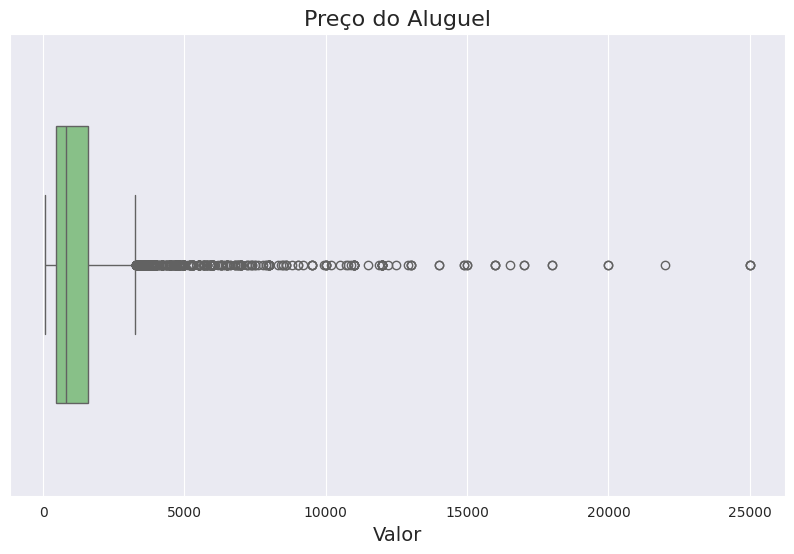

In [ ]:
# Boxplot da variável dependente (Y)
ax = sns.boxplot(dados, x='valor', width=0.6)
ax.figure.set_size_inches(10,6)
ax.set_title('Preço do Aluguel', fontsize=16)
ax.set_xlabel('Valor', fontsize=14)
ax

<Axes: title={'center': 'Distribuição de Frequências'}, xlabel='Valor', ylabel='Count'>

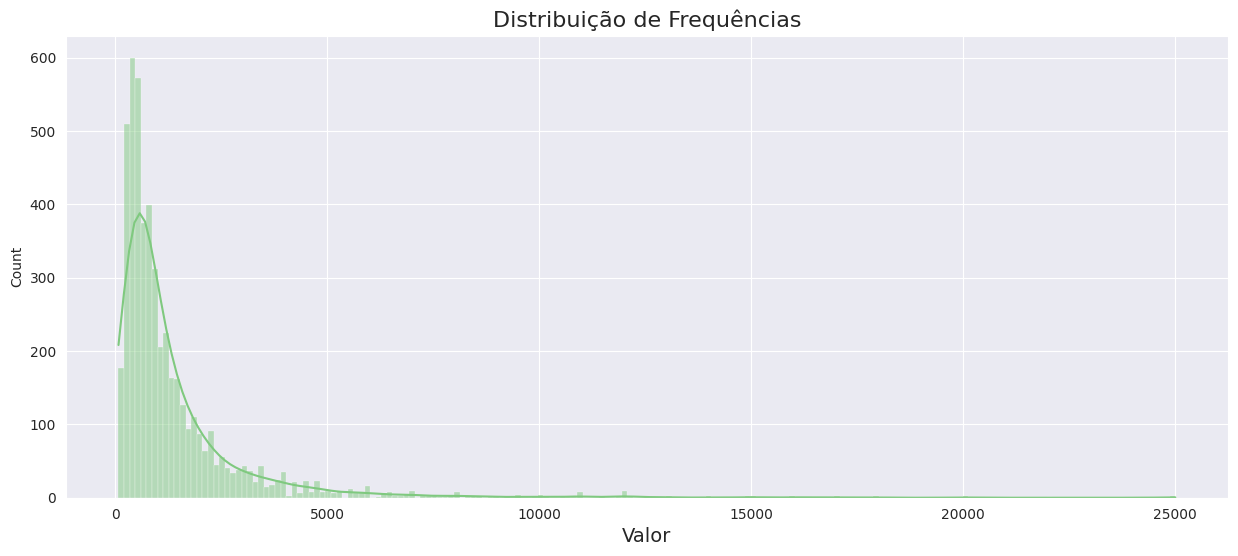

In [ ]:
# Distribuição da frequência
ax = sns.histplot(dados, x='valor', kde=True)
ax.figure.set_size_inches(15,6)
ax.set_title('Distribuição de Frequências', fontsize=16)
ax.set_xlabel('Valor', fontsize=14)
ax

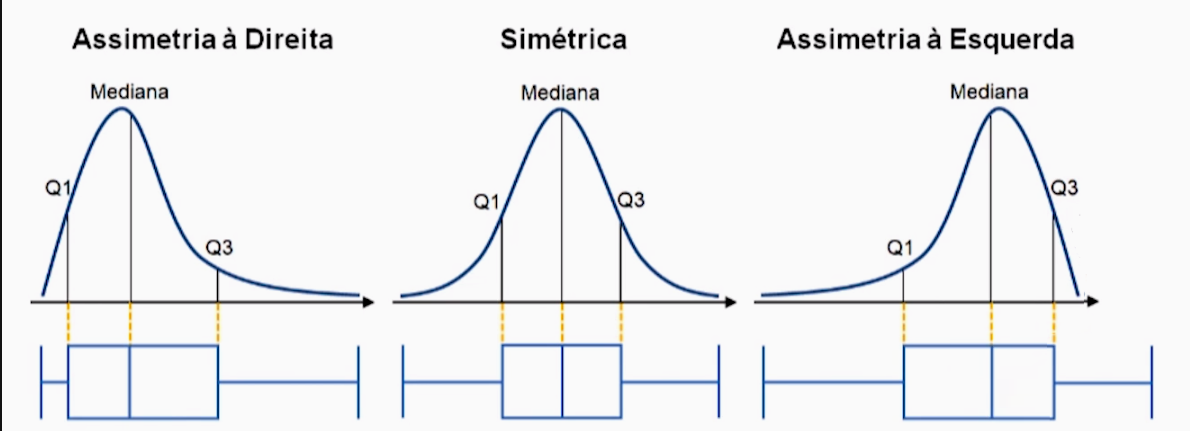

# Dispersão entre as variáveis

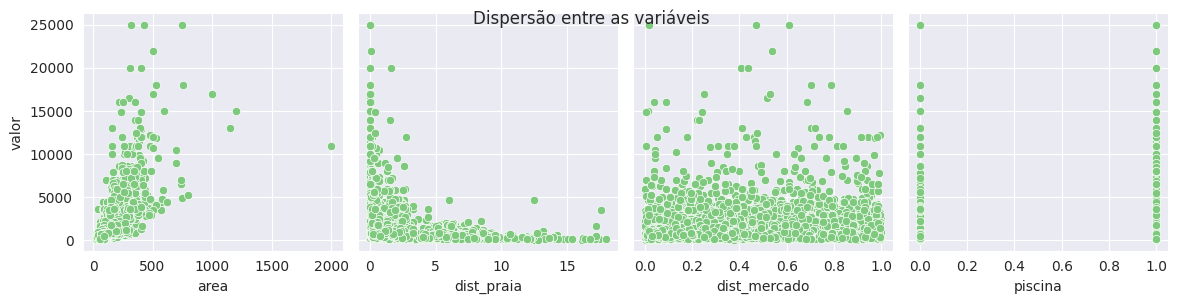

In [ ]:
ax = sns.pairplot(dados, y_vars='valor', x_vars=['area', 'dist_praia', 'dist_mercado', 'piscina'], height=3)
ax.fig.suptitle('Dispersão entre as variáveis')
ax

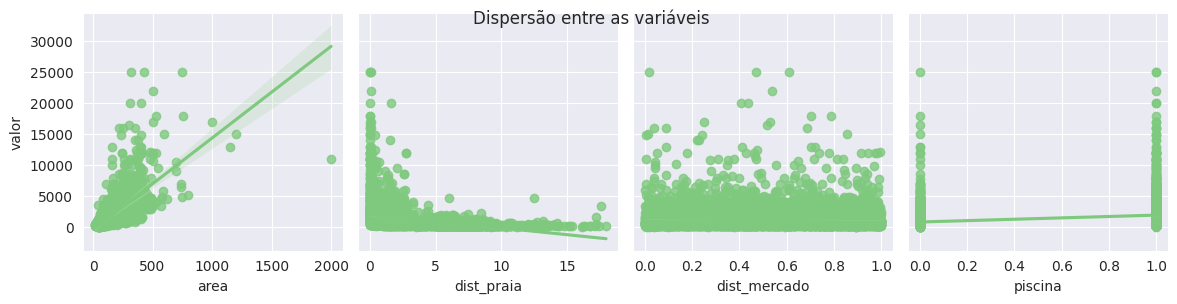

In [ ]:
ax = sns.pairplot(dados, y_vars='valor', x_vars=['area', 'dist_praia', 'dist_mercado', 'piscina'], height=3, kind='reg')
ax.fig.suptitle('Dispersão entre as variáveis')
ax

# 3. Transformação de Variáveis

# Transformando os dados em LOG

In [ ]:
import numpy as np

In [ ]:
dados['log_valor'] = np.log(dados['valor'])
dados['log_area'] = np.log(dados['area'])
dados['log_dist_praia'] = np.log(dados['dist_praia'] + 1) # quando o valor min é zero
dados['log_dist_mercado'] = np.log(dados['dist_mercado'] + 1)

In [ ]:
dados.head()

,valor,area,dist_praia,dist_mercado,piscina,log_valor,log_area,log_dist_praia,log_dist_mercado
0,4600.0,280,0.241,0.794,1,8.433812,5.634790,0.215918,0.584448
1,900.0,208,0.904,0.134,1,6.802395,5.337538,0.643957,0.125751
2,2550.0,170,0.060,0.423,1,7.843849,5.135798,0.058269,0.352767
3,550.0,100,2.883,0.525,0,6.309918,4.605170,1.356608,0.421994
4,2200.0,164,0.240,0.192,0,7.696213,5.099866,0.215111,0.175633


# Distribuição de frequências da variável dependente transformada (Y)

<Axes: title={'center': 'Distribuição de Frequências'}, xlabel='Valor', ylabel='Count'>

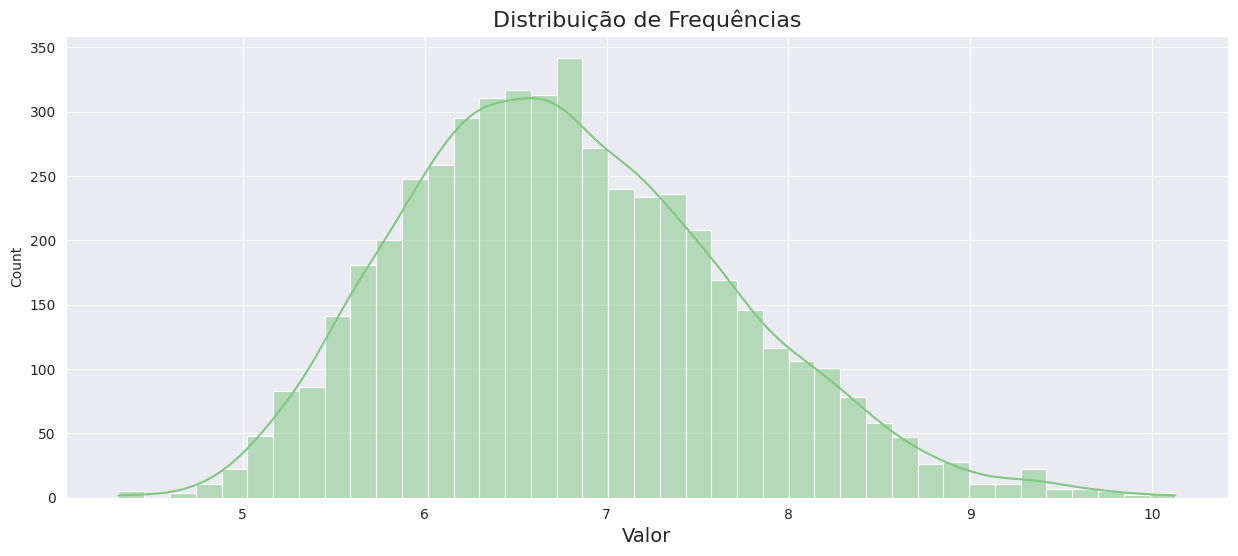

In [ ]:
# Distribuição da frequência
ax = sns.histplot(dados, x='log_valor', kde=True)
ax.figure.set_size_inches(15,6)
ax.set_title('Distribuição de Frequências', fontsize=16)
ax.set_xlabel('Valor', fontsize=14)
ax

# Verificando a relação linear

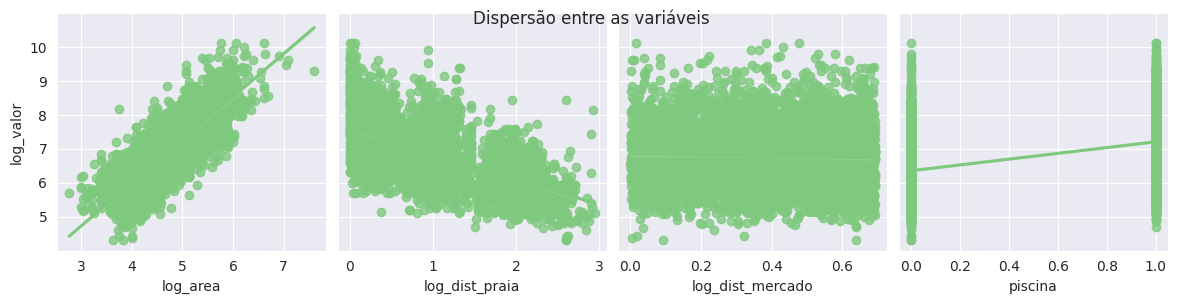

In [ ]:
ax = sns.pairplot(dados, y_vars='log_valor', x_vars=['log_area', 'log_dist_praia', 'log_dist_mercado', 'piscina'], height=3, kind='reg')
ax.fig.suptitle('Dispersão entre as variáveis')
ax

# 4. Regressão Linear

# Regressão Linear com StatsModels

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
y = dados['log_valor']

x = dados[['log_area', 'log_dist_praia', 'log_dist_mercado', 'piscina']]

In [ ]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
print(f'x_treino: {x_treino.shape}')
print(f'x_teste: {x_teste.shape}')
print(f'y_treino: {y_treino.shape}')
print(f'y_teste: {y_teste.shape}')

x_treino: (3500, 4)
x_teste: (1500, 4)
y_treino: (3500,)
y_teste: (1500,)


In [ ]:
import statsmodels.api as sm

In [ ]:
# Adicionando uma constante
x_treino_com_constante = sm.add_constant(x_treino)

In [ ]:
x_treino_com_constante.head()

,const,log_area,log_dist_praia,log_dist_mercado,piscina
1840,1.0,5.267858,0.406132,0.672434,1
2115,1.0,4.532599,0.669879,0.225541,0
4437,1.0,4.867534,1.036737,0.281412,1
1146,1.0,4.553877,0.384582,0.361861,1
2486,1.0,3.951244,1.717754,0.271553,0


In [ ]:
modelo_statsmodels = sm.OLS(y_treino, x_treino_com_constante).fit()

# Avaliando o modelo

In [ ]:
print(modelo_statsmodels.summary())

                            OLS Regression Results                            
Dep. Variable:              log_valor   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     3735.
Date:                Fri, 14 Nov 2025   Prob (F-statistic):               0.00
Time:                        16:32:25   Log-Likelihood:                -1703.9
No. Observations:                3500   AIC:                             3418.
Df Residuals:                    3495   BIC:                             3449.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.5668      0.064  

Observando o Teste de significância individual , notamos que a log_dist_mercado não ajuda o modelo , portanto teremos que excluir ele

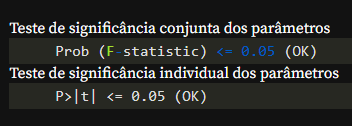

In [ ]:
y = dados['log_valor']

x = dados[['log_area', 'log_dist_praia', 'piscina']]

x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.3, random_state=42)

# Adicionando uma constante
x_treino_com_constante = sm.add_constant(x_treino)

modelo_statsmodels = sm.OLS(y_treino, x_treino_com_constante).fit()

print(modelo_statsmodels.summary())

                            OLS Regression Results                            
Dep. Variable:              log_valor   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     4980.
Date:                Fri, 14 Nov 2025   Prob (F-statistic):               0.00
Time:                        16:32:25   Log-Likelihood:                -1704.2
No. Observations:                3500   AIC:                             3416.
Df Residuals:                    3496   BIC:                             3441.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.5779      0.062     41.

# 5. Regressão Linear com Sklearn

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:
modelo_lr = LinearRegression()
modelo_lr.fit(x_treino, y_treino)

LinearRegression()

In [ ]:
print('Métricas conjunto treino:')
print(f'R²: {metrics.r2_score(y_treino, modelo_lr.predict(x_treino))}')
print(f'MAE: {metrics.mean_absolute_error(y_treino, modelo_lr.predict(x_treino))}')
print(f'RMSE: {np.sqrt(metrics.mean_absolute_error(y_treino, modelo_lr.predict(x_treino)))}')

print('\nMétricas conjunto teste:')
print(f'R²: {metrics.r2_score(y_teste, modelo_lr.predict(x_teste))}')
print(f'MAE: {metrics.mean_absolute_error(y_teste, modelo_lr.predict(x_teste))}')
print(f'RMSE: {np.sqrt(metrics.mean_absolute_error(y_teste, modelo_lr.predict(x_teste)))}')

Métricas conjunto treino:
R²: 0.8103741770962766
MAE: 0.3060695469528771
RMSE: 0.5532355257509021

Métricas conjunto teste:
R²: 0.8089406906960852
MAE: 0.3047462838251509
RMSE: 0.552038299237608


# Árvore de Decisão

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
modelo_dt = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo_dt.fit(x_treino, y_treino)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
print('Métricas conjunto treino:')
print(f'R²: {metrics.r2_score(y_treino, modelo_dt.predict(x_treino))}')
print(f'MAE: {metrics.mean_absolute_error(y_treino, modelo_dt.predict(x_treino))}')
print(f'RMSE: {np.sqrt(metrics.mean_absolute_error(y_treino, modelo_dt.predict(x_treino)))}')

print('\nMétricas conjunto teste:')
print(f'R²: {metrics.r2_score(y_teste, modelo_dt.predict(x_teste))}')
print(f'MAE: {metrics.mean_absolute_error(y_teste, modelo_dt.predict(x_teste))}')
print(f'RMSE: {np.sqrt(metrics.mean_absolute_error(y_teste, modelo_dt.predict(x_teste)))}')

Métricas conjunto treino:
R²: 0.8237441211431602
MAE: 0.2921580089951652
RMSE: 0.5405164280529919

Métricas conjunto teste:
R²: 0.8009775263825475
MAE: 0.30641434534135653
RMSE: 0.5535470579285527


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
modelo_rf = RandomForestRegressor(max_depth=5, n_estimators=100, random_state=42)
modelo_rf.fit(x_treino, y_treino)

RandomForestRegressor(max_depth=5, random_state=42)

In [ ]:
print('Métricas conjunto treino:')
print(f'R²: {metrics.r2_score(y_treino, modelo_rf.predict(x_treino))}')
print(f'MAE: {metrics.mean_absolute_error(y_treino, modelo_rf.predict(x_treino))}')
print(f'RMSE: {np.sqrt(metrics.mean_absolute_error(y_treino, modelo_rf.predict(x_treino)))}')

print('\nMétricas conjunto teste:')
print(f'R²: {metrics.r2_score(y_teste, modelo_rf.predict(x_teste))}')
print(f'MAE: {metrics.mean_absolute_error(y_teste, modelo_rf.predict(x_teste))}')
print(f'RMSE: {np.sqrt(metrics.mean_absolute_error(y_teste, modelo_rf.predict(x_teste)))}')

Métricas conjunto treino:
R²: 0.840001088806938
MAE: 0.27800310473447415
RMSE: 0.5272599972826254

Métricas conjunto teste:
R²: 0.8200354136102114
MAE: 0.29153229120822516
RMSE: 0.5399373030345516


# Modelo XGBoost

In [ ]:
import xgboost as xgb

In [ ]:
modelo_xgb = xgb.XGBRegressor(objective='reg:squarederror',max_depth=5, random_state=123, n_estimators=100)
modelo_xgb.fit(x_treino, y_treino)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
print('Métricas conjunto treino:')
print(f'R²: {metrics.r2_score(y_treino, modelo_xgb.predict(x_treino))}')
print(f'MAE: {metrics.mean_absolute_error(y_treino, modelo_xgb.predict(x_treino))}')
print(f'RMSE: {np.sqrt(metrics.mean_absolute_error(y_treino, modelo_xgb.predict(x_treino)))}')

print('\nMétricas conjunto teste:')
print(f'R²: {metrics.r2_score(y_teste, modelo_xgb.predict(x_teste))}')
print(f'MAE: {metrics.mean_absolute_error(y_teste, modelo_xgb.predict(x_teste))}')
print(f'RMSE: {np.sqrt(metrics.mean_absolute_error(y_teste, modelo_xgb.predict(x_teste)))}')

Métricas conjunto treino:
R²: 0.9172806292608159
MAE: 0.1984484637334814
RMSE: 0.44547554785137355

Métricas conjunto teste:
R²: 0.8233077492329113
MAE: 0.2875984214873594
RMSE: 0.5362820353949584


# Obtendo previsões

In [ ]:
entrada = x_teste[0:1]
entrada

,log_area,log_dist_praia,piscina
1501,3.951244,1.966972,0


In [ ]:
modelo_xgb.predict(entrada)[0]

np.float32(5.6250286)

In [ ]:
np.exp(modelo_xgb.predict(entrada)[0])

np.float32(277.2802)

# Criando um Simulador Simples

In [ ]:
area = 250
dist_praia = 0.5
piscina = 1

entrada = [[np.log(area), np.log(dist_praia + 1), piscina]]

print(f'Valor do Aluguel : R${np.exp(modelo_xgb.predict(entrada)[0])}')

Valor do Aluguel : R$2549.33740234375


# Salvando o Modelo

In [ ]:
import joblib

In [ ]:
joblib.dump(modelo_xgb, 'modelo.pkl')

['modelo.pkl']